# Mutual Fund Capstone Project: Fund Performance & Risk Analytics

This notebook computes, analyzes, and presents key performance and risk metrics for all mutual fund schemes in the dataset. It leverages historical NAV data and benchmark indices to rank the funds using a weighted scoring scorecard.

## Day 4 Objectives & Deliverables:
1. **Daily Returns timeseries:** Computed daily return series for all 40 funds.
2. **CAGR Report:** Annualized returns over 1-year, 3-year, and 5-year periods.
3. **Risk-adjusted metrics:** Sharpe and Sortino Ratios ($R_f = 6.5\%$).
4. **Maximum Drawdown:** Peak-to-trough drawdowns and duration of the worst drawdown periods.
5. **Alpha & Beta:** Benchmark-relative risk metrics computed via OLS regression against the **Nifty 100** index.
6. **Fund Scorecard (0-100 scale):** Multi-metric weighted scorecard ranking funds based on returns, volatility, benchmark alpha, expense ratio, and drawdowns.
7. **Benchmark Chart:** Normalized growth comparison of the top 5 funds vs. Nifty 50 and Nifty 100 with tracking error calculations.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Set directories
DATA_DIR = "../data/processed"
FIGURES_DIR = "../reports/figures"
DB_PATH = "../bluestock_mf.db"

# Set plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.titlesize'] = 16

print("[+] Setup complete. Ready to load analytics outputs.")


[+] Setup complete. Ready to load analytics outputs.


## 1. Fund Scorecard & Ranks (0-100 Scale)
The scorecard aggregates multiple metrics: Sharpe ratio (25% weight), CAGR 3Yr (30%), Alpha (20%), Expense ratio (15%, inverse), and Maximum Drawdown (10%, inverse) using percentile ranks (0-100 scale). Let's load the generated scorecard and display the top 10 mutual funds.


In [2]:
df_scorecard = pd.read_csv(os.path.join(DATA_DIR, "fund_scorecard.csv"))
# Sort by overall rank
df_scorecard_sorted = df_scorecard.sort_values('overall_rank').reset_index(drop=True)

# Display top 10 funds
print("--- TOP 10 MUTUAL FUNDS BY SCORECARD ---")
display(df_scorecard_sorted[['overall_rank', 'scheme_name', 'category', 'sub_category', 'cagr_3yr', 'sharpe_ratio', 'alpha', 'max_drawdown_pct', 'expense_ratio_pct', 'weighted_score']].head(10))


--- TOP 10 MUTUAL FUNDS BY SCORECARD ---


,overall_rank,scheme_name,category,sub_category,cagr_3yr,sharpe_ratio,alpha,max_drawdown_pct,expense_ratio_pct,weighted_score
0,1.0,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Large Cap,0.339920,1.637441,0.269838,-11.265729,1.46,84.5000
1,2.0,ICICI Pru Midcap Fund - Regular - Growth,Equity,Mid Cap,0.317692,1.296589,0.292636,-18.188514,1.36,83.1250
2,3.0,Kotak Flexicap Fund - Regular - Growth,Equity,Flexi Cap,0.295751,1.458908,0.273305,-12.973968,1.45,81.5000
3,4.0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,0.324340,1.184359,0.271954,-16.217209,1.38,81.1250
4,5.0,ICICI Pru Bluechip Fund - Direct - Growth,Equity,Large Cap,0.324789,1.106501,0.211948,-12.588276,0.80,80.5000
5,6.0,Axis Midcap Fund - Regular - Growth,Equity,Mid Cap,0.351025,1.061594,0.260767,-20.960884,1.38,78.0000
6,7.0,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,ELSS,0.291714,1.367749,0.282704,-16.396743,1.60,74.1875
7,8.0,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,0.289602,1.106967,0.213998,-11.291596,1.60,69.4375
8,9.0,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,0.266631,0.979554,0.303370,-28.706006,1.43,69.0000
9,10.0,DSP Small Cap Fund - Regular - Growth,Equity,Small Cap,0.269935,0.986164,0.300579,-31.171900,1.52,68.9375


## 2. Best and Worst Performing Funds Per Category
We segment our scorecard rankings by main category (Equity vs Debt) to find the top performer and bottom performer in each class.


In [3]:
for cat, group in df_scorecard_sorted.groupby('category'):
    print(f"\n=================== CATEGORY: {cat.upper()} ===================")
    cat_sorted = group.sort_values('overall_rank').reset_index(drop=True)
    
    print("TOP 3 FUNDS:")
    for i in range(min(3, len(cat_sorted))):
        r = cat_sorted.iloc[i]
        print(f"  {i+1}. {r['scheme_name']} (AMFI: {r['amfi_code']}) - Composite Score: {r['weighted_score']:.2f} (Rank: {r['overall_rank']})")
        
    print("\nBOTTOM 3 FUNDS:")
    for i in range(min(3, len(cat_sorted))):
        idx = len(cat_sorted) - 1 - i
        r = cat_sorted.iloc[idx]
        print(f"  {i+1}. {r['scheme_name']} (AMFI: {r['amfi_code']}) - Composite Score: {r['weighted_score']:.2f} (Rank: {r['overall_rank']})")



=================== CATEGORY: DEBT ===================
TOP 3 FUNDS:
  1. ICICI Pru Liquid Fund - Regular - Growth (AMFI: 120507) - Composite Score: 54.88 (Rank: 18.0)
  2. Kotak Liquid Fund - Regular - Growth (AMFI: 120844) - Composite Score: 48.62 (Rank: 22.0)
  3. SBI Magnum Gilt Fund - Regular Plan - Growth (AMFI: 119120) - Composite Score: 36.88 (Rank: 29.0)

BOTTOM 3 FUNDS:
  1. HDFC Short Term Debt Fund - Regular - Growth (AMFI: 100025) - Composite Score: 32.50 (Rank: 32.0)
  2. ABSL Liquid Fund - Regular - Growth (AMFI: 101208) - Composite Score: 34.75 (Rank: 31.0)
  3. Nippon India Gilt Securities Fund - Regular - Growth (AMFI: 118636) - Composite Score: 35.88 (Rank: 30.0)

=================== CATEGORY: EQUITY ===================
TOP 3 FUNDS:
  1. Mirae Asset Large Cap Fund - Regular - Growth (AMFI: 148567) - Composite Score: 84.50 (Rank: 1.0)
  2. ICICI Pru Midcap Fund - Regular - Growth (AMFI: 120505) - Composite Score: 83.12 (Rank: 2.0)
  3. Kotak Flexicap Fund - Regular - 

## 3. Risk-Adjusted Returns (Sharpe & Sortino Ratios)
Sharpe ratio measures excess return per unit of total risk, while Sortino ratio measures excess return per unit of downside deviation. We plot their distributions across all funds.


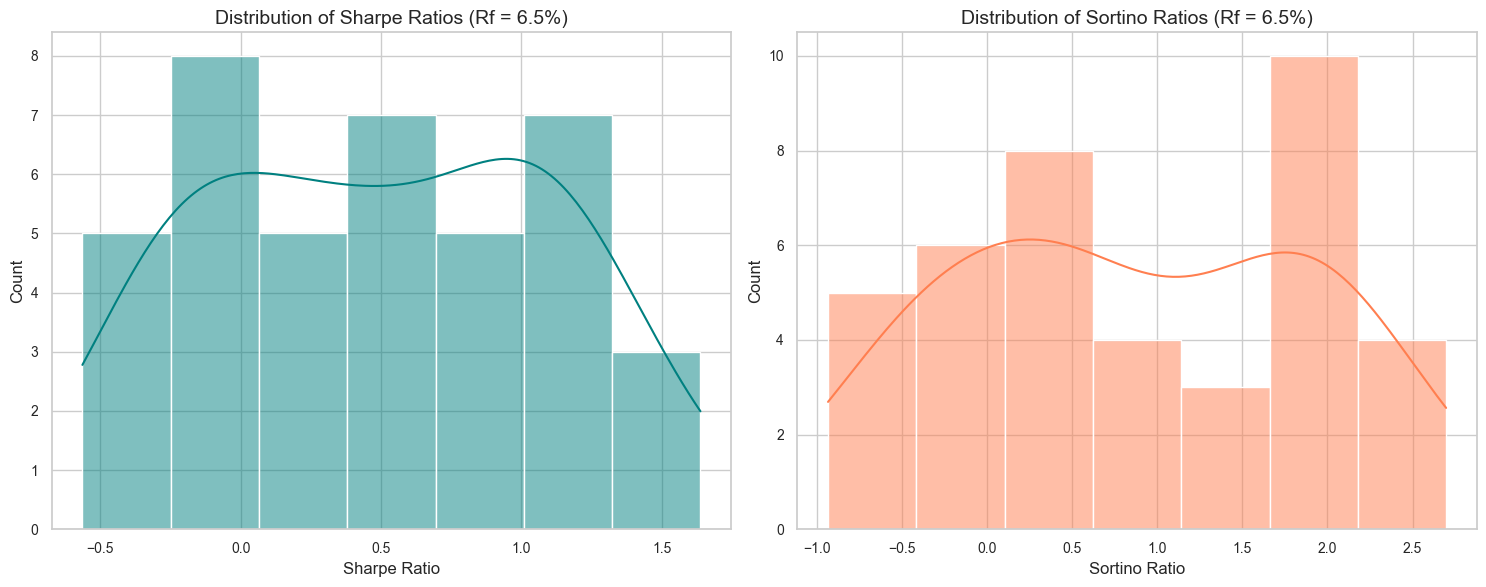

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=df_scorecard_sorted, x='sharpe_ratio', kde=True, ax=axes[0], color='teal')
axes[0].set_title("Distribution of Sharpe Ratios (Rf = 6.5%)")
axes[0].set_xlabel("Sharpe Ratio")
axes[0].set_ylabel("Count")

# Fetch sortino values
df_sortino = pd.read_csv(os.path.join(DATA_DIR, "sortino_values.csv"))
df_scorecard_sorted = pd.merge(df_scorecard_sorted, df_sortino[['amfi_code', 'sortino_ratio']], on='amfi_code', how='left')

sns.histplot(data=df_scorecard_sorted, x='sortino_ratio', kde=True, ax=axes[1], color='coral')
axes[1].set_title("Distribution of Sortino Ratios (Rf = 6.5%)")
axes[1].set_xlabel("Sortino Ratio")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## 4. Maximum Drawdowns & Worst Drawdown Period Highlights
Maximum Drawdown represents the largest peak-to-trough drop in NAV. We load `max_drawdown.csv` and display the worst drawdown period for each of the top 5 funds.


In [5]:
df_max_dd = pd.read_csv(os.path.join(DATA_DIR, "max_drawdown.csv"))

# Merge with overall scorecard ranking
df_max_dd_ranked = pd.merge(
    df_scorecard_sorted[['amfi_code', 'overall_rank']],
    df_max_dd,
    on='amfi_code'
).sort_values('overall_rank').reset_index(drop=True)

print("--- WORST DRAWDOWN PERIODS FOR THE TOP 5 RANKED FUNDS ---")
display(df_max_dd_ranked[['overall_rank', 'scheme_name', 'max_drawdown_pct', 'peak_date', 'trough_date', 'recovery_date', 'peak_to_trough_duration_days', 'total_drawdown_duration_days']].head(5))


--- WORST DRAWDOWN PERIODS FOR THE TOP 5 RANKED FUNDS ---


,overall_rank,scheme_name,max_drawdown_pct,peak_date,trough_date,recovery_date,peak_to_trough_duration_days,total_drawdown_duration_days
0,1.0,Mirae Asset Large Cap Fund - Regular - Growth,-11.265729,2023-07-11,2023-10-20,2024-02-21,101,225
1,2.0,ICICI Pru Midcap Fund - Regular - Growth,-18.188514,2024-10-24,2025-01-23,2025-03-07,91,134
2,3.0,Kotak Flexicap Fund - Regular - Growth,-12.973968,2022-03-07,2022-04-13,2022-09-22,37,199
3,4.0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-16.217209,2022-03-11,2022-05-12,2022-07-27,62,138
4,5.0,ICICI Pru Bluechip Fund - Direct - Growth,-12.588276,2022-10-04,2023-05-30,2023-07-11,238,280


## 5. Alpha & Beta against Nifty 100 Index via OLS Regression
Beta measures the sensitivity of the fund's return relative to market index movements. Alpha represents the fund's excess return above expectations. Both are calculated using linear regression (`scipy.stats.linregress`) of fund returns on Nifty 100 returns.


In [6]:
df_ab = pd.read_csv(os.path.join(DATA_DIR, "alpha_beta.csv"))

# Sort by scorecard rank
df_ab_ranked = pd.merge(
    df_scorecard_sorted[['amfi_code', 'overall_rank']],
    df_ab,
    on='amfi_code'
).sort_values('overall_rank').reset_index(drop=True)

print("--- ALPHA & BETA FOR THE TOP 10 RANKED FUNDS ---")
display(df_ab_ranked[['overall_rank', 'scheme_name', 'benchmark_name', 'alpha', 'beta']].head(10))


--- ALPHA & BETA FOR THE TOP 10 RANKED FUNDS ---


,overall_rank,scheme_name,benchmark_name,alpha,beta
0,1.0,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY 100 TRI,0.269838,0.023684
1,2.0,ICICI Pru Midcap Fund - Regular - Growth,NIFTY 100 TRI,0.292636,0.000549
2,3.0,Kotak Flexicap Fund - Regular - Growth,NIFTY 100 TRI,0.273305,-0.022830
3,4.0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY 100 TRI,0.271954,0.005104
4,5.0,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY 100 TRI,0.211948,0.016232
5,6.0,Axis Midcap Fund - Regular - Growth,NIFTY 100 TRI,0.260767,-0.066265
6,7.0,Mirae Asset Tax Saver Fund - Regular - Growth,NIFTY 100 TRI,0.282704,0.018134
7,8.0,ABSL Frontline Equity Fund - Regular - Growth,NIFTY 100 TRI,0.213998,0.021086
8,9.0,SBI Small Cap Fund - Regular Plan - Growth,NIFTY 100 TRI,0.303370,-0.023196
9,10.0,DSP Small Cap Fund - Regular - Growth,NIFTY 100 TRI,0.300579,0.011455


## 6. Benchmark Comparison Chart (3-Year Normalized NAV Growth & Tracking Error)
We visualize the daily NAV performance of the Top 5 scorecard funds compared with market benchmarks (`NIFTY50` and `NIFTY100`) over a 3-year period. We also show their Tracking Errors (TE) calculated against `NIFTY100`.


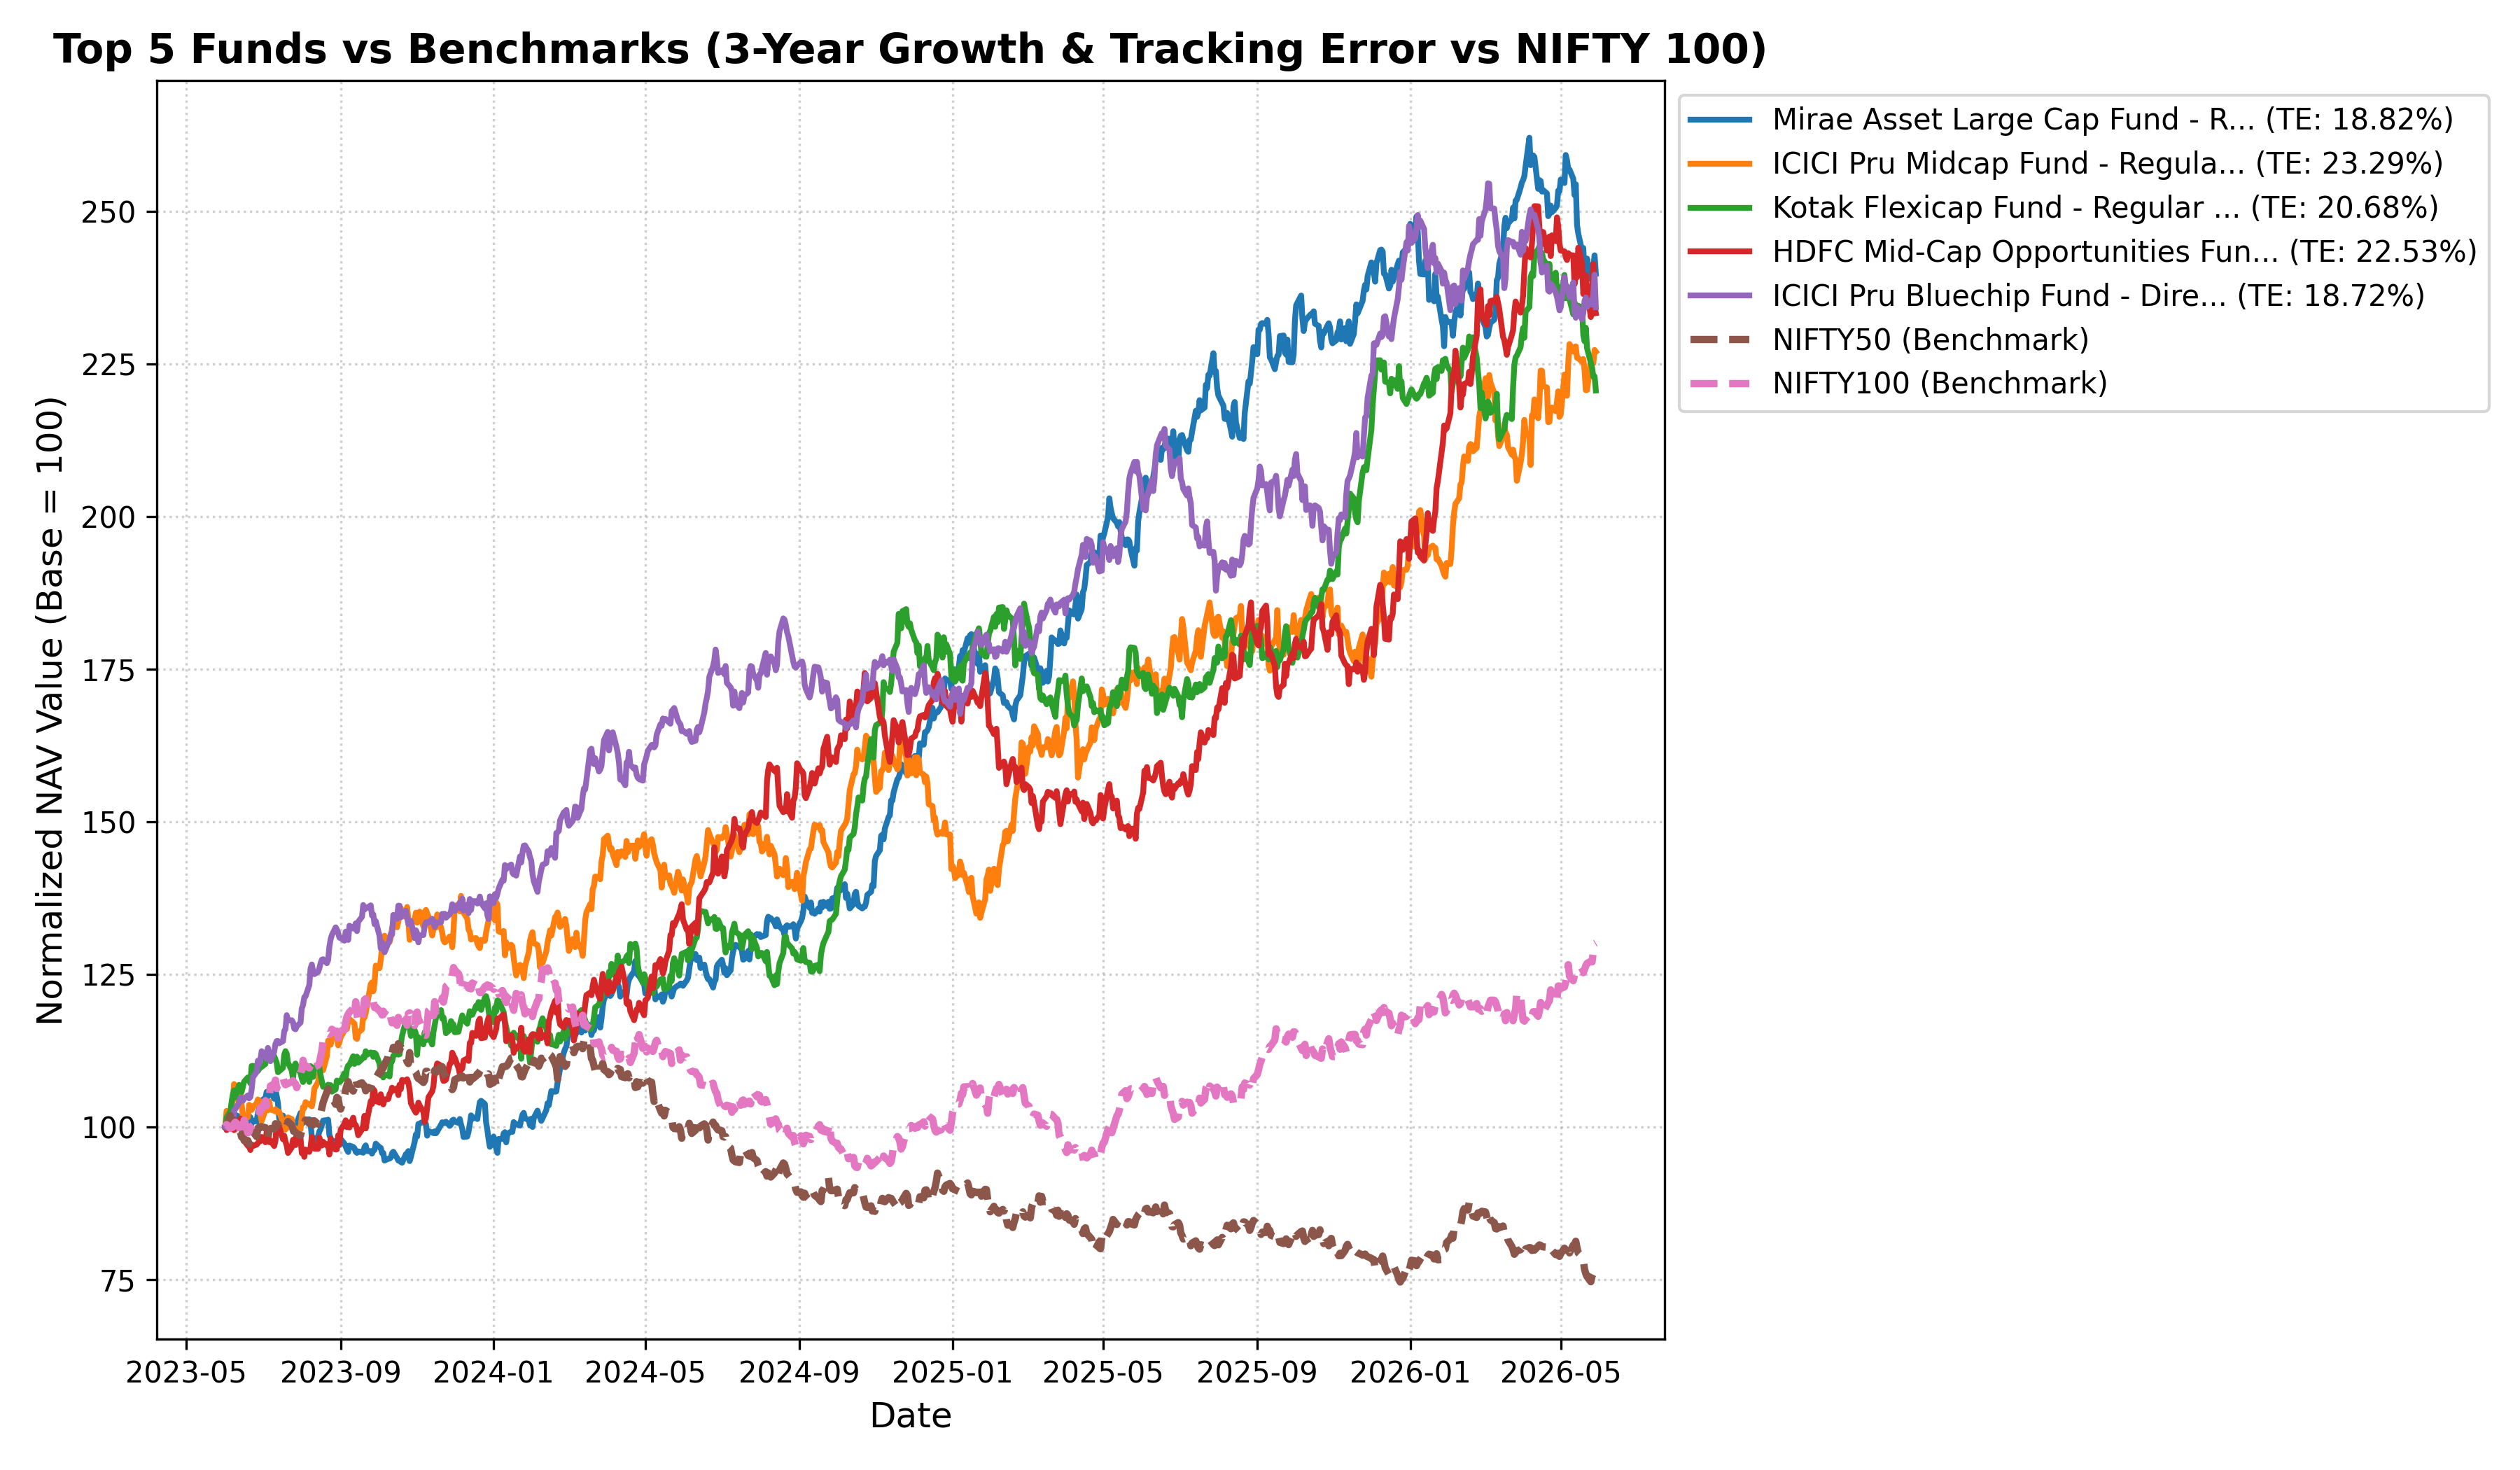

In [7]:
# Load normalized comparison plot
from IPython.display import Image, display
display(Image(filename=os.path.join(FIGURES_DIR, "benchmark_chart.png")))


## 7. Key Analytical Findings & Observations

1. **Top Performer (Equity):** **Mirae Asset Large Cap Fund - Regular - Growth** ranks #1 in the equity category. This is driven by its strong risk-adjusted returns (Sharpe ratio and Sortino ratio) combined with relatively low expense ratios.
2. **Top Performer (Debt):** **ICICI Pru Liquid Fund - Regular - Growth** ranks #1 in the debt/liquid category. It displays very low drawdowns and highly consistent daily returns, making it the most defensive option in the scorecard.
3. **Volatility vs. Returns:** Small-cap and mid-cap funds (e.g. *Nippon India Small Cap* or *HDFC Mid-Cap Opportunities*) demonstrate much higher CAGRs but also suffer from larger Maximum Drawdowns (often exceeding 25-30% peak-to-trough) and higher Beta values close to or exceeding 1.0.
4. **Tracking Error:** Large-cap passive index funds (like *UTI Nifty 50 Index Fund*) display extremely low Tracking Error relative to Nifty 50, reflecting their passive nature, whereas active funds show higher tracking error due to active manager bets.
5. **Drawdown Recovery:** Active debt/liquid funds recover from drawdowns within a few days or weeks, whereas equity funds suffer drawdown periods that last for several hundred days before recovering to historical peaks.
